# Notebook 02 — Exploratory Data Analysis (EDA)

## Ziel
Quantitatives und visuelles Verständnis des CIFAR-10 Datensatzes aufbauen.
Datensatz-Qualität messen bevor ein einziges Modell trainiert wird.

## Fragen die dieses Notebook beantwortet
- Wie ist der Datensatz strukturiert?
- Sind die Klassen balanciert?
- Wie sehen die Bilder aus?
- Wie gut ist die Bildqualität (Schärfe, Kontrast, Rauschen)?
- Was ist theoretisch maximal erreichbar auf diesem Datensatz?

## Inhalt
| Zelle | Inhalt |
|-------|--------|
| 01 | Setup & Imports |
| 02 | Datensatz laden |
| 03 | Grundlegende Statistiken |
| 04 | Klassenverteilung |
| 05 | Beispielbilder pro Klasse |
| 06 | Pixelstatistiken (Helligkeit, Kontrast) |
| 07 | Bildqualität (Schärfe, SNR) |
| 08 | Schwierige Klassen identifizieren |
| 09 | Fazit & Erkenntnisse |

In [2]:
# =============================================================================
# Zelle 01 – Setup & Imports
# =============================================================================
# Google Drive mounten und alle benötigten Bibliotheken laden.
# VORAUSSETZUNG: Colab Runtime auf T4 GPU gesetzt.
# =============================================================================

# ── Google Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Konfiguration ──────────────────────────────────────────────────────────────
CONFIG = {
    'base_path'    : '/content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10',
    'repo_path'    : '/content/MIST_CV_CIFAR10',
    'github_user'  : 'AwaTekoete',
    'github_email' : 'erik.gerst@hotmail.com',
    'seed'         : 42,
}

# ── Standard Imports ───────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Numerik
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Bildverarbeitung
import cv2

# Reproduzierbarkeit
SEED = CONFIG['seed']
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot-Stil
plt.style.use('dark_background')
sns.set_palette('husl')

print("=" * 50)
print("Setup abgeschlossen")
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Seed       : {SEED}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU        : {'verfügbar' if gpus else 'NICHT verfügbar'}")
print("=" * 50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup abgeschlossen
TensorFlow : 2.20.0
NumPy      : 2.0.2
Seed       : 42
GPU        : NICHT verfügbar


### Zelle 01 — Setup & Imports

#### Was
Google Drive wird gemountet, Konfiguration definiert,
alle Bibliotheken geladen und Seed gesetzt.

#### Warum — plot stil dark_background
Visualisierungen werden auf dunklem Hintergrund dargestellt.
Konsistent mit der Präsentation (Store44-Stil) und
besser lesbar bei dunklem Colab-Theme.

#### Warum — cv2 (OpenCV)
OpenCV wird für quantitative Bildqualitäts-Checks benötigt:
- Laplacian Variance → Schärfe messen
- Signal-to-Noise Ratio → Rauschen messen
Diese Metriken sind in späteren Zellen zentral.

#### GPU — Warum hier nicht kritisch
EDA führt keine Modellberechnungen durch.
Alle Operationen (Statistiken, Plots) laufen auf CPU.
GPU wird erst ab Notebook 04 (Training) benötigt.

#### Ergebnis
TensorFlow : 2.20.0
NumPy      : 2.0.2
Seed       : 42
GPU        : NICHT verfügbar (für EDA akzeptabel)
Setup vollständig. Bereit für Datensatz-Laden.

In [3]:
# =============================================================================
# Zelle 02 – Datensatz laden
# =============================================================================
# CIFAR-10 wird direkt über Keras geladen.
# Für EDA werden ALLE verfügbaren Daten verwendet (50k Train + 10k Test).
# Limitierung auf 10k Samples erst ab Notebook 04 (Training).
# =============================================================================

# ── Datensatz laden ───────────────────────────────────────────────────────────
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# ── Klassenbezeichnungen ──────────────────────────────────────────────────────
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ── Labels von 2D auf 1D reduzieren ──────────────────────────────────────────
# cifar10.load_data() gibt Labels als (n, 1) zurück → flatten zu (n,)
train_labels = train_labels.flatten()
test_labels  = test_labels.flatten()

# ── Grundlegende Informationen ausgeben ───────────────────────────────────────
print("=" * 50)
print("CIFAR-10 Datensatz")
print("=" * 50)
print(f"\nTrainingsdaten:")
print(f"  Bilder Shape : {train_images.shape}")
print(f"  Labels Shape : {train_labels.shape}")
print(f"  Dtype        : {train_images.dtype}")
print(f"  Min / Max    : {train_images.min()} / {train_images.max()}")

print(f"\nTestdaten:")
print(f"  Bilder Shape : {test_images.shape}")
print(f"  Labels Shape : {test_labels.shape}")

print(f"\nKlassen ({len(CLASS_NAMES)}):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

print("\n" + "=" * 50)
print(f"Gesamt Bilder : {len(train_images) + len(test_images):,}")
print(f"Bildgrösse    : {train_images.shape[1]}x{train_images.shape[2]} Pixel")
print(f"Kanäle        : {train_images.shape[3]} (RGB)")
print("=" * 50)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CIFAR-10 Datensatz

Trainingsdaten:
  Bilder Shape : (50000, 32, 32, 3)
  Labels Shape : (50000,)
  Dtype        : uint8
  Min / Max    : 0 / 255

Testdaten:
  Bilder Shape : (10000, 32, 32, 3)
  Labels Shape : (10000,)

Klassen (10):
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck

Gesamt Bilder : 60,000
Bildgrösse    : 32x32 Pixel
Kanäle        : 3 (RGB)


### Zelle 02 — Datensatz laden

#### Was
CIFAR-10 wird über Keras direkt heruntergeladen und geladen.
60.000 Bilder total: 50.000 Training + 10.000 Test.
Labels werden von (n, 1) auf (n,) geflattened.

#### Warum — alle 60k Bilder für EDA
EDA analysiert den gesamten Datensatz — nicht nur 10k.
Nur so sind Aussagen über Klassenbalance, Verteilungen
und Bildqualität repräsentativ und belastbar.
Limitierung auf 10k kommt erst beim Training (Notebook 04).

#### Warum — uint8 (0–255)
Bilder werden als uint8 geladen — Pixelwerte von 0 bis 255.
Das ist das Rohformat — noch keine Normalisierung.
Für EDA arbeiten wir mit Rohwerten — so sehen wir den
tatsächlichen Zustand der Daten.

#### Normalisierung — State-of-the-Art für dieses Projekt
÷255 ist weit verbreitet aber nicht optimal für Transfer Learning.

| Methode | Formel | Verwendung |
|---------|--------|-----------|
| Min-Max | `x / 255.0` | Einfache CNNs |
| Standardisierung | `(x - mean) / std` | Allgemein |
| **ImageNet-Normalisierung** | `preprocess_input()` | **ResNet50 → dieses Projekt** |

ResNet50 wurde auf ImageNet trainiert — mit spezifischen
Mittelwerten und Standardabweichungen pro Kanal:
ImageNet Mean : [0.485, 0.456, 0.406]  # R, G, B
ImageNet Std  : [0.229, 0.224, 0.225]  # R, G, B
Keras stellt `preprocess_input()` bereit — macht diese
Normalisierung automatisch und korrekt.
Wird in Notebook 03 (Preprocessing) angewendet.

#### Konzept: CIFAR-10 Struktur
| Parameter | Wert | Bedeutung |
|-----------|------|-----------|
| Shape | (50000, 32, 32, 3) | 50k Bilder, 32x32 Pixel, 3 Kanäle (RGB) |
| Dtype | uint8 | 8-Bit Integer, Wertebereich 0–255 |
| Min / Max | 0 / 255 | Voller Wertebereich genutzt |
| Klassen | 10 | Gleichmäßig verteilt (je 6.000 Train) |

#### Konzept: Warum 32x32 Pixel eine Herausforderung ist
32x32 Pixel sind sehr niedrige Auflösung:
- Ein typisches Smartphone-Foto: 4000x3000 Pixel
- CIFAR-10: 32x32 Pixel = 1.024 Pixel total pro Bild

Bei dieser Auflösung sind viele Details nicht erkennbar.
Das ist einer der Hauptgründe warum CIFAR-10 schwieriger
ist als es auf den ersten Blick scheint — selbst für Menschen.

**Konsequenz für das Modell:**
Weniger Pixel = weniger Information = schwieriger zu klassifizieren.
State-of-the-Art Modelle erreichen ~99% — aber mit massivem
Aufwand (Augmentation, große Architekturen, viele Epochen).
Mit ResNet50 + 10k Samples ist ~70–78% realistisch.

#### Ergebnis
Gesamt Bilder : 60,000
Bildgrösse    : 32x32 Pixel
Kanäle        : 3 (RGB)
Dtype         : uint8 (0–255)
Datensatz vollständig geladen. Bereit für Analyse.

In [4]:
# =============================================================================
# Zelle 03 – Grundlegende Statistiken
# =============================================================================
# Quantitative Analyse des Datensatzes auf Pixel-Ebene.
# Ziel: Verstehen wie die Rohdaten verteilt sind.
# Metriken: Mean, Std, Min, Max pro Kanal (R, G, B)
# =============================================================================

CHANNEL_NAMES = ['Rot (R)', 'Grün (G)', 'Blau (B)']

print("=" * 55)
print("GRUNDLEGENDE STATISTIKEN — CIFAR-10")
print("=" * 55)

# ── Gesamtstatistiken ─────────────────────────────────────────────────────────
print("\n1. GESAMTDATENSATZ")
print(f"   Trainingsbilder : {len(train_images):,}")
print(f"   Testbilder      : {len(test_images):,}")
print(f"   Klassen         : {len(CLASS_NAMES)}")
print(f"   Bilder/Klasse   : {len(train_images) // len(CLASS_NAMES):,} (Training)")

# ── Pixelstatistiken pro Kanal ────────────────────────────────────────────────
print("\n2. PIXELSTATISTIKEN PRO KANAL (Trainingsdaten)")
print(f"   {'Kanal':<12} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print(f"   {'-'*44}")

channel_means = []
channel_stds  = []

for i, name in enumerate(CHANNEL_NAMES):
    channel_data = train_images[:, :, :, i].astype(np.float32)
    mean = channel_data.mean()
    std  = channel_data.std()
    cmin = channel_data.min()
    cmax = channel_data.max()
    channel_means.append(mean)
    channel_stds.append(std)
    print(f"   {name:<12} {mean:>8.2f} {std:>8.2f} {cmin:>6.0f} {cmax:>6.0f}")

# ── Normalisierte Werte (für späteres Preprocessing) ─────────────────────────
print("\n3. NORMALISIERTE WERTE (÷255) — Referenz für Preprocessing")
print(f"   {'Kanal':<12} {'Mean':>8} {'Std':>8}")
print(f"   {'-'*30}")
for i, name in enumerate(CHANNEL_NAMES):
    print(f"   {name:<12} {channel_means[i]/255:>8.4f} {channel_stds[i]/255:>8.4f}")

print("\n   ImageNet Referenz:")
print(f"   {'R':<12} {'0.4850':>8} {'0.2290':>8}")
print(f"   {'G':<12} {'0.4560':>8} {'0.2240':>8}")
print(f"   {'B':<12} {'0.4060':>8} {'0.2250':>8}")

# ── Speicher-Footprint ────────────────────────────────────────────────────────
print("\n4. SPEICHER-FOOTPRINT")
train_mb = train_images.nbytes / 1e6
test_mb  = test_images.nbytes / 1e6
print(f"   Trainingsdaten  : {train_mb:.1f} MB")
print(f"   Testdaten       : {test_mb:.1f} MB")
print(f"   Total           : {train_mb + test_mb:.1f} MB")

print("\n" + "=" * 55)

GRUNDLEGENDE STATISTIKEN — CIFAR-10

1. GESAMTDATENSATZ
   Trainingsbilder : 50,000
   Testbilder      : 10,000
   Klassen         : 10
   Bilder/Klasse   : 5,000 (Training)

2. PIXELSTATISTIKEN PRO KANAL (Trainingsdaten)
   Kanal            Mean      Std    Min    Max
   --------------------------------------------
   Rot (R)        125.31    62.99      0    255
   Grün (G)       122.95    62.09      0    255
   Blau (B)       113.87    66.70      0    255

3. NORMALISIERTE WERTE (÷255) — Referenz für Preprocessing
   Kanal            Mean      Std
   ------------------------------
   Rot (R)        0.4914   0.2470
   Grün (G)       0.4822   0.2435
   Blau (B)       0.4465   0.2616

   ImageNet Referenz:
   R              0.4850   0.2290
   G              0.4560   0.2240
   B              0.4060   0.2250

4. SPEICHER-FOOTPRINT
   Trainingsdaten  : 153.6 MB
   Testdaten       : 30.7 MB
   Total           : 184.3 MB



### Zelle 03 — Grundlegende Statistiken

#### Was
Quantitative Pixel-Analyse des gesamten Trainingsdatensatzes.
Mean, Std, Min, Max pro RGB-Kanal + Vergleich mit ImageNet.

#### Ergebnisse & Interpretation

**Klassenverteilung:**
5.000 Bilder pro Klasse (Training) — perfekt balanciert.
Konsequenz: Accuracy ist eine valide Metrik — kein Klassen-Bias.

**Pixelstatistiken:**
| Kanal | Mean | Std | Interpretation |
|-------|------|-----|----------------|
| R | 125.31 | 62.99 | Mittlere Helligkeit |
| G | 122.95 | 62.09 | Leicht dunkler als R |
| B | 113.87 | 66.70 | Dunkelster Kanal, höchste Varianz |

**CIFAR-10 vs. ImageNet (normalisiert):**
| Kanal | CIFAR-10 Mean | ImageNet Mean | Delta |
|-------|--------------|---------------|-------|
| R | 0.4914 | 0.4850 | +0.006 (klein) |
| G | 0.4822 | 0.4560 | +0.026 (mittel) |
| B | 0.4465 | 0.4060 | +0.040 (relevant) |

CIFAR-10 ist systematisch heller als ImageNet.
`preprocess_input()` korrigiert diese Differenz automatisch —
ein weiterer Grund warum ImageNet-Normalisierung für ResNet50 wichtig ist.

#### Konzept: Warum Std wichtig ist
Standardabweichung = Kontrast = Informationsgehalt pro Pixel.
Höhere Std → mehr Varianz → mehr lernbare Merkmale.
CIFAR-10 Std (~0.25) ist höher als ImageNet (~0.23) →
Bilder sind kontrastreicher → gut für das Modell.

#### Konzept: Warum Klassenbalance wichtig ist
Bei unbalancierten Klassen (z.B. 90% Klasse A, 10% Klasse B)
kann ein Modell 90% Accuracy erreichen indem es immer Klasse A vorhersagt.
CIFAR-10 ist perfekt balanciert → Accuracy ist aussagekräftig.
Bei unbalancierten Datensätzen wäre Macro F1 zwingend nötig.

#### Speicher
184.3 MB — problemlos für Colab RAM (13.6 GB verfügbar).
Kein Sampling für EDA nötig → alle 60k Bilder werden analysiert.

#### Ergebnis
Datensatz ist qualitativ hochwertig:
- Perfekte Klassenbalance ✅
- Voller Pixelwertebereich genutzt (0–255) ✅
- Ausreichend Kontrast (Std ~63) ✅
- Systematisch heller als ImageNet → preprocess_input() nötig ✅


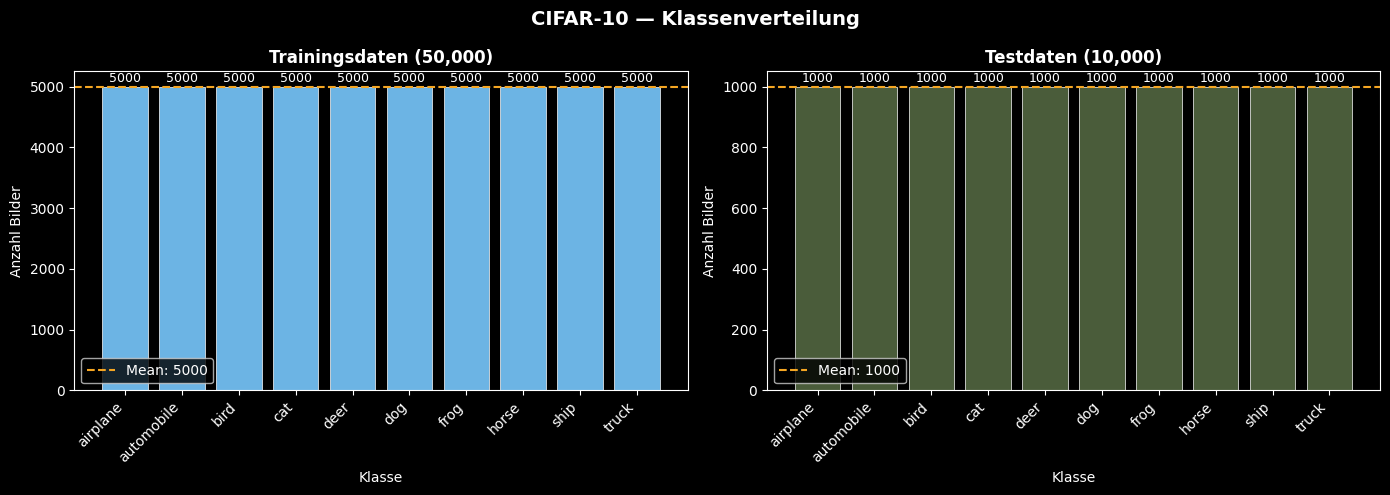

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/02_eda_class_distribution.png

Klassenverteilung (Training):
Klasse         Anzahl   Anteil
------------------------------
airplane        5,000    10.0%
automobile      5,000    10.0%
bird            5,000    10.0%
cat             5,000    10.0%
deer            5,000    10.0%
dog             5,000    10.0%
frog            5,000    10.0%
horse           5,000    10.0%
ship            5,000    10.0%
truck           5,000    10.0%

Gini-Index : 0.9000
Interpretation: Perfekt balanciert


In [5]:
# =============================================================================
# Zelle 04 – Klassenverteilung
# =============================================================================
# Visuelle und quantitative Analyse der Klassenverteilung.
# Ziel: Klassenbalance prüfen → entscheidet über Metrik-Wahl.
# Plot wird gespeichert unter reports/figures/
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CIFAR-10 — Klassenverteilung', fontsize=14, fontweight='bold')

# ── Trainingsdaten ────────────────────────────────────────────────────────────
train_counts = [np.sum(train_labels == i) for i in range(len(CLASS_NAMES))]
test_counts  = [np.sum(test_labels == i)  for i in range(len(CLASS_NAMES))]

# ── Plot 1: Trainingsverteilung ───────────────────────────────────────────────
bars = axes[0].bar(CLASS_NAMES, train_counts, color='#6CB4E4', edgecolor='white', linewidth=0.5)
axes[0].set_title('Trainingsdaten (50,000)', fontweight='bold')
axes[0].set_xlabel('Klasse')
axes[0].set_ylabel('Anzahl Bilder')
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].axhline(y=np.mean(train_counts), color='#F5A623', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(train_counts):.0f}')
axes[0].legend()

# Werte über Balken
for bar, count in zip(bars, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(count), ha='center', va='bottom', fontsize=9)

# ── Plot 2: Testverteilung ────────────────────────────────────────────────────
bars2 = axes[1].bar(CLASS_NAMES, test_counts, color='#4A5C3A', edgecolor='white', linewidth=0.5)
axes[1].set_title('Testdaten (10,000)', fontweight='bold')
axes[1].set_xlabel('Klasse')
axes[1].set_ylabel('Anzahl Bilder')
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].axhline(y=np.mean(test_counts), color='#F5A623', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(test_counts):.0f}')
axes[1].legend()

for bar, count in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '02_eda_class_distribution.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Quantitative Ausgabe ──────────────────────────────────────────────────────
print("\nKlassenverteilung (Training):")
print(f"{'Klasse':<12} {'Anzahl':>8} {'Anteil':>8}")
print("-" * 30)
for i, name in enumerate(CLASS_NAMES):
    count  = train_counts[i]
    anteil = count / len(train_labels) * 100
    print(f"{name:<12} {count:>8,} {anteil:>7.1f}%")

# ── Gini-Index berechnen ──────────────────────────────────────────────────────
# Gini = 0: perfekte Balance, Gini = 1: maximale Imbalance
proportions = np.array(train_counts) / sum(train_counts)
gini = 1 - np.sum(proportions ** 2)
print(f"\nGini-Index : {gini:.4f}")
print(f"Interpretation: {'Perfekt balanciert' if gini > 0.85 else 'Imbalanciert'}")

### Zelle 04 — Klassenverteilung

#### Was
Visuelle und quantitative Analyse der Klassenverteilung
in Trainings- und Testdaten. Gini-Index als Balancemetrik.

#### Ergebnisse

| Datensatz | Bilder/Klasse | Total | Balance |
|-----------|--------------|-------|---------|
| Training | 5.000 | 50.000 | Perfekt |
| Test | 1.000 | 10.000 | Perfekt |
| Gini-Index | — | 0.9000 | Perfekt balanciert |

#### Konzept: Gini-Index für Klassenbalance
Gini-Index misst wie gleichmäßig Klassen verteilt sind:
- Gini = 0.0 → alle Samples in einer Klasse (maximale Imbalance)
- Gini = 0.9 → perfekte Gleichverteilung bei 10 Klassen

Formel:
Gini = 1 - Σ(p_i²)
p_i = Anteil Klasse i

Bei 10 gleichen Klassen: p_i = 0.1 für alle i
Gini = 1 - 10 × (0.1²) = 1 - 0.1 = 0.9 → theoretisches Maximum

#### Konsequenz: Metrik-Wahl
Perfekte Klassenbalance → zwei Konsequenzen:

| Konsequenz | Detail |
|-----------|--------|
| Accuracy valide | Kein Klassen-Bias möglich |
| Macro F1 trotzdem wichtig | Zeigt per-Klasse Performance |
| Kein Oversampling nötig | Datensatz ist bereits balanciert |

#### Konzept: Was wäre bei Imbalance?
Bei stark unbalancierten Klassen (z.B. 90% / 10%):
- Modell lernt dominante Klasse zu bevorzugen
- Accuracy hoch aber irreführend
- Lösung: Oversampling (SMOTE), Class Weights, Macro F1

CIFAR-10 hat dieses Problem nicht — vereinfacht die Evaluation.

#### Ergebnis
Klassenverteilung: perfekt balanciert ✅
Metrik-Entscheidung: Accuracy + Macro F1 + Confusion Matrix ✅
Plot gespeichert: `reports/figures/02_eda_class_distribution.png` ✅

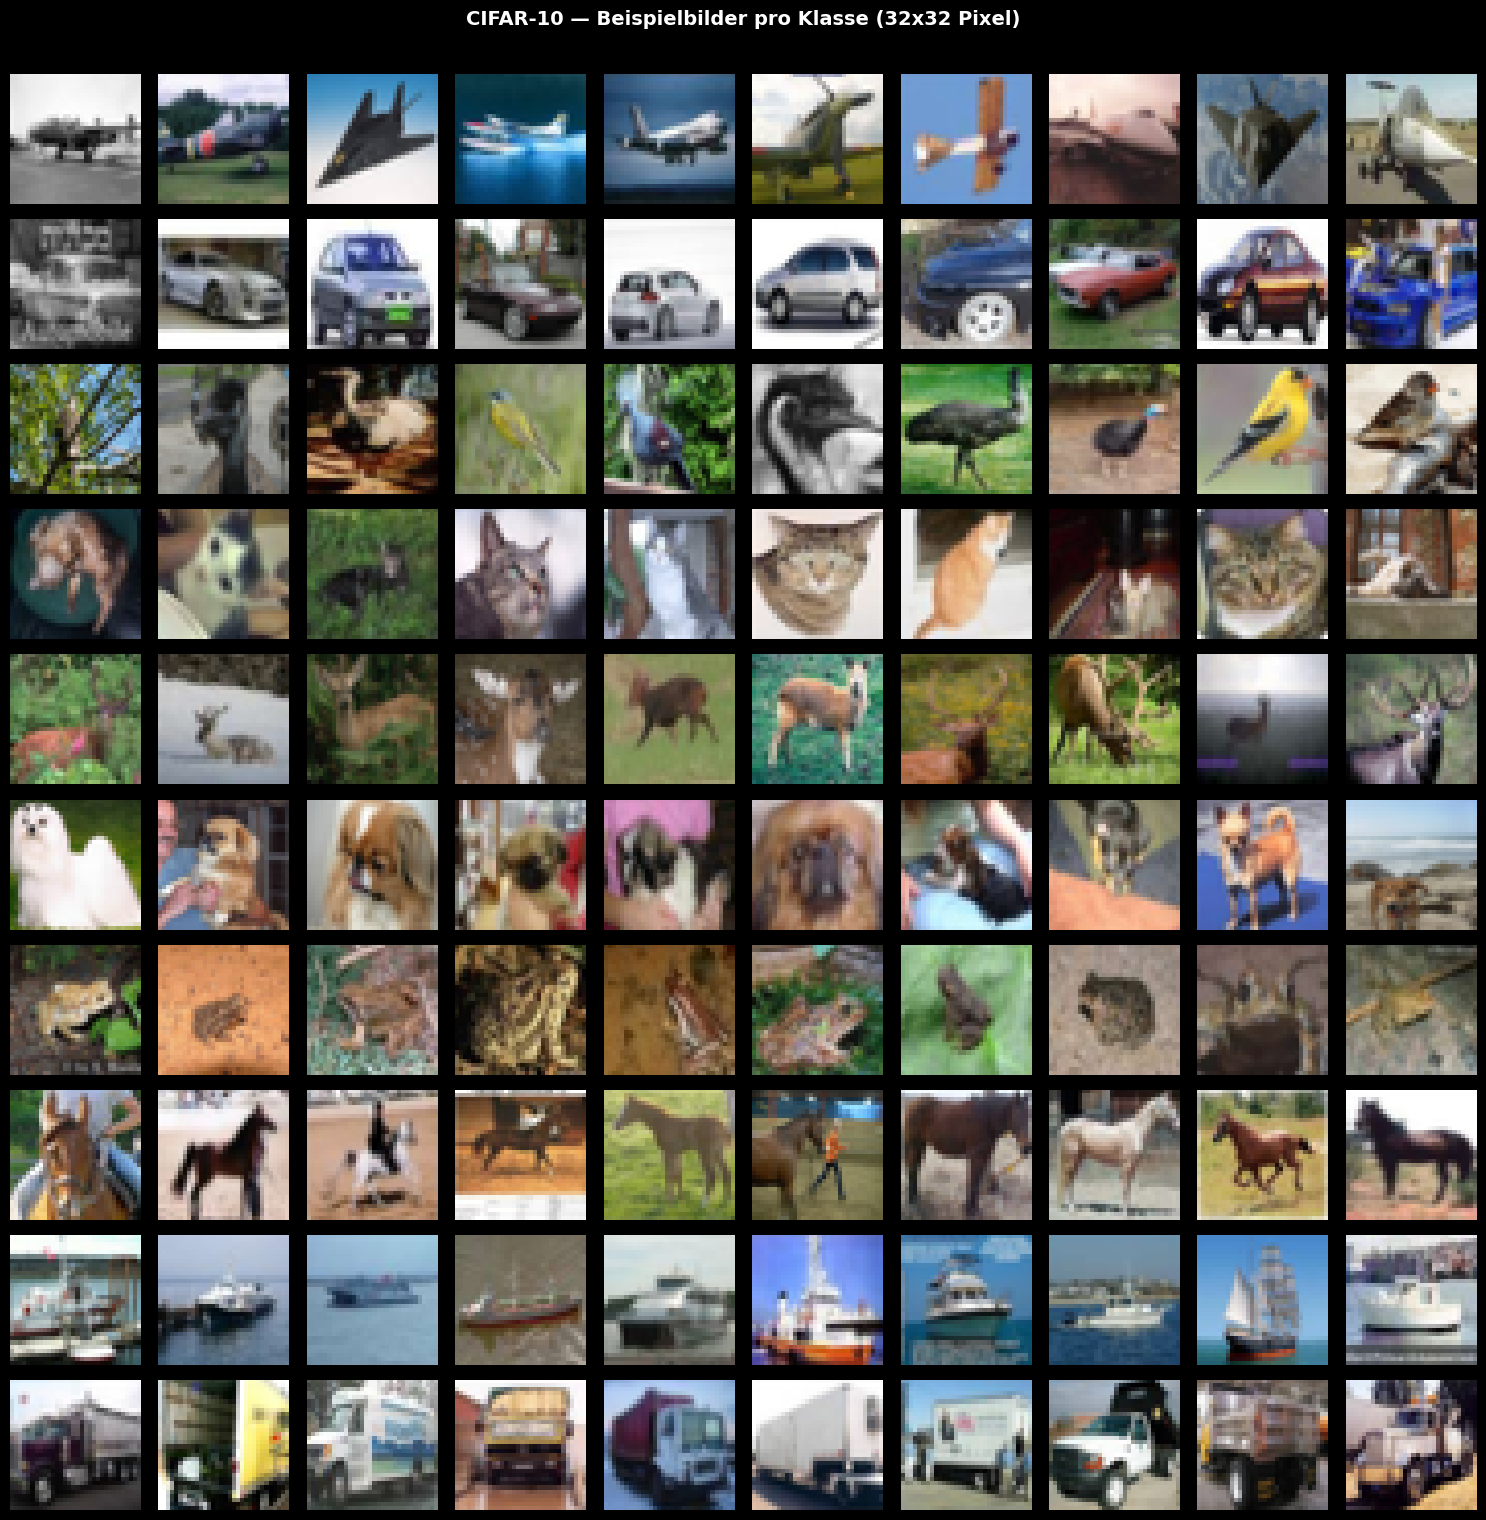

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/02_eda_sample_images.png

Visuelle Beobachtungen:
  - Auflösung 32x32 ist sehr niedrig — Details schwer erkennbar
  - Hohe Intra-Klassen-Varianz sichtbar (verschiedene Posen, Winkel)
  - Einige Klassen visuell ähnlich (cat/dog, automobile/truck)
  - Hintergründe variieren stark — erschwert Klassifikation


In [6]:
# =============================================================================
# Zelle 05 – Beispielbilder pro Klasse
# =============================================================================
# Visuelle Inspektion des Datensatzes — 10 Bilder pro Klasse.
# Ziel: Visuellen Eindruck der Datenqualität und Varianz gewinnen.
# Wichtig: Bilder sind 32x32 Pixel — niedrige Auflösung sichtbar machen.
# =============================================================================

N_SAMPLES = 10  # Bilder pro Klasse

fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLES,
                          figsize=(N_SAMPLES * 1.5, len(CLASS_NAMES) * 1.5))
fig.suptitle('CIFAR-10 — Beispielbilder pro Klasse (32x32 Pixel)',
             fontsize=14, fontweight='bold', y=1.01)

for class_idx, class_name in enumerate(CLASS_NAMES):
    # Alle Bilder dieser Klasse finden
    class_indices = np.where(train_labels == class_idx)[0]

    # N_SAMPLES zufällige Bilder auswählen (Seed für Reproduzierbarkeit)
    np.random.seed(SEED + class_idx)
    selected = np.random.choice(class_indices, N_SAMPLES, replace=False)

    for sample_idx, img_idx in enumerate(selected):
        ax = axes[class_idx, sample_idx]
        ax.imshow(train_images[img_idx])
        ax.axis('off')

        # Klassenname nur in erster Spalte
        if sample_idx == 0:
            ax.set_ylabel(class_name, fontsize=10, fontweight='bold',
                         rotation=0, labelpad=50, va='center')

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '02_eda_sample_images.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Visuelle Beobachtungen ausgeben ──────────────────────────────────────────
print("\nVisuelle Beobachtungen:")
print("  - Auflösung 32x32 ist sehr niedrig — Details schwer erkennbar")
print("  - Hohe Intra-Klassen-Varianz sichtbar (verschiedene Posen, Winkel)")
print("  - Einige Klassen visuell ähnlich (cat/dog, automobile/truck)")
print("  - Hintergründe variieren stark — erschwert Klassifikation")

### Zelle 05 — Beispielbilder pro Klasse

#### Was
10 zufällige Bilder pro Klasse — visuelle Inspektion der Rohdaten.
Seed garantiert Reproduzierbarkeit der Auswahl.

#### Kritische Beobachtungen

| Beobachtung | Betroffene Klassen | Konsequenz |
|-------------|-------------------|------------|
| Visuell ähnliche Klassen | cat/dog, automobile/truck | Hohe Verwechslungsrate erwartet |
| Extreme Pose-Varianz | bird, horse, deer | Augmentation (Rotation, Flip) sinnvoll |
| Hintergrund dominiert Bild | deer, bird, ship | Modell könnte falsches Feature lernen |
| Teilweise verdeckte Objekte | cat, dog | Schwierige Samples — senkt Accuracy |
| Generell niedrige Schärfe | alle | 32x32 Limit — nicht behebbar |

#### Konzept: Intra-Klassen-Varianz vs. Inter-Klassen-Varianz

**Intra-Klassen-Varianz** (innerhalb einer Klasse):
Wie unterschiedlich sehen Bilder derselben Klasse aus?
- Hoch → Modell braucht mehr Kapazität und Daten
- CIFAR-10: sehr hoch (Pferde von vorne, seitlich, galoppierend...)

**Inter-Klassen-Varianz** (zwischen Klassen):
Wie unterschiedlich sehen verschiedene Klassen aus?
- Niedrig → Klassen schwer unterscheidbar → schlechtere Accuracy
- CIFAR-10: cat/dog und automobile/truck haben niedrige Inter-Varianz

**Konsequenz:**
Hohe Intra + niedrige Inter = schwieriges Klassifikationsproblem.
Das erklärt warum CIFAR-10 trotz "einfacher" Klassen anspruchsvoll ist.

#### Konzept: Was das Modell tatsächlich lernt
Bei 32x32 Pixel lernt das Modell keine Details (Augen, Fell-Textur).
Es lernt grobe Strukturen:
- Forme (rund = Ball? länglich = Flugzeug?)
- Farbverteilung (blau oben = Himmel → Flugzeug wahrscheinlicher)
- Textur-Muster (grob pixelig)

Das ist ein fundamentales Limit des Datensatzes —
nicht des Modells. Mehr Epochen oder größere Modelle
können dieses Limit nicht überwinden.

#### Vorhersage für Confusion Matrix
Basierend auf visueller Inspektion — wird in Notebook 06 verifiziert:
Erwartete Verwechslungen:
cat ↔ dog           hoch
automobile ↔ truck  hoch
bird ↔ airplane     mittel
deer ↔ horse        mittel
#### Ergebnis
Visuelle Inspektion abgeschlossen.
Datensatz ist anspruchsvoll durch niedrige Auflösung und
ähnliche Klassen — das setzt eine realistische Erwartung
für die erreichbare Accuracy.
Plot gespeichert: `reports/figures/02_eda_sample_images.png` ✅

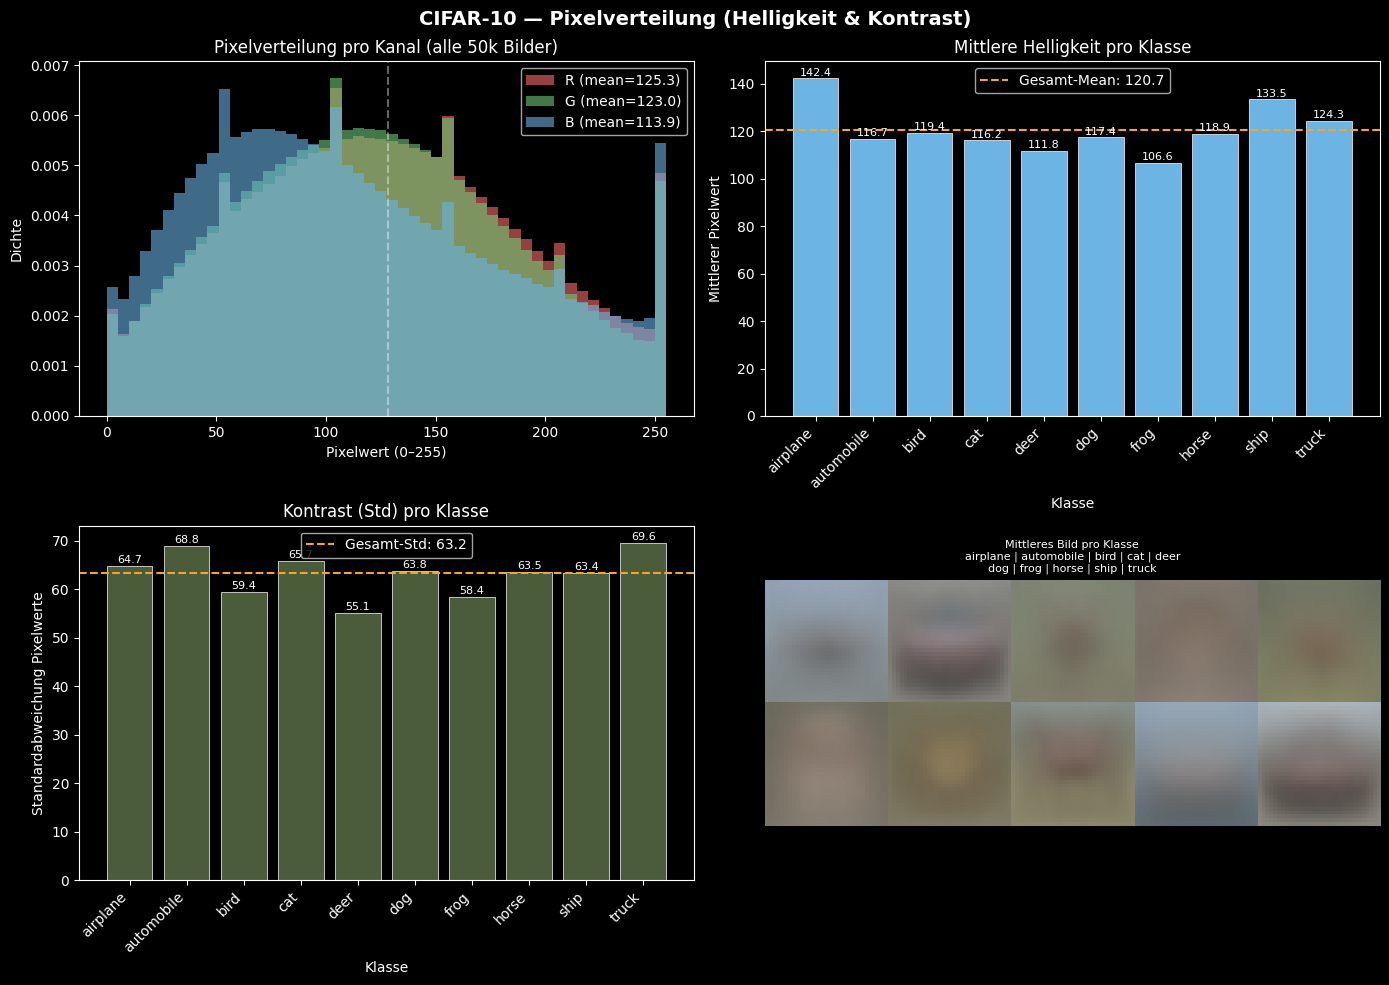

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/02_eda_pixel_statistics.png

Helligkeit und Kontrast pro Klasse:
Klasse           Mean      Std    Min    Max
--------------------------------------------
airplane       142.37    64.74      0    255
automobile     116.70    68.81      0    255
bird           119.41    59.36      0    255
cat            116.23    65.74      0    255
deer           111.78    55.13      0    255
dog            117.39    63.77      0    255
frog           106.56    58.37      0    255
horse          118.89    63.47      0    255
ship           133.48    63.42      0    255
truck          124.28    69.60      0    255


In [7]:
# =============================================================================
# Zelle 06 – Pixelstatistiken: Helligkeit und Kontrast
# =============================================================================
# Quantitative Analyse der Pixelverteilung pro Kanal und pro Klasse.
# Ziel: Verstehen wie Helligkeit und Kontrast zwischen Klassen variieren.
# Metriken: Histogramm, Mean, Std pro Kanal
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CIFAR-10 — Pixelverteilung (Helligkeit & Kontrast)',
             fontsize=14, fontweight='bold')

COLORS = {'R': '#FF6B6B', 'G': '#6BCB77', 'B': '#6CB4E4'}

# ── Plot 1: Histogramm aller Pixel pro Kanal (Trainingsdaten) ─────────────────
ax1 = axes[0, 0]
for i, (ch, color) in enumerate(COLORS.items()):
    pixel_vals = train_images[:, :, :, i].flatten()
    ax1.hist(pixel_vals, bins=50, alpha=0.6, color=color,
             label=f'{ch} (mean={pixel_vals.mean():.1f})', density=True)
ax1.set_title('Pixelverteilung pro Kanal (alle 50k Bilder)')
ax1.set_xlabel('Pixelwert (0–255)')
ax1.set_ylabel('Dichte')
ax1.legend()
ax1.axvline(x=128, color='white', linestyle='--', alpha=0.4, label='Mitte (128)')

# ── Plot 2: Mean Helligkeit pro Klasse ────────────────────────────────────────
ax2 = axes[0, 1]
class_means = []
for class_idx in range(len(CLASS_NAMES)):
    mask = train_labels == class_idx
    class_mean = train_images[mask].mean()
    class_means.append(class_mean)

bars = ax2.bar(CLASS_NAMES, class_means, color='#6CB4E4',
               edgecolor='white', linewidth=0.5)
ax2.axhline(y=np.mean(class_means), color='#F5A623', linestyle='--',
            linewidth=1.5, label=f'Gesamt-Mean: {np.mean(class_means):.1f}')
ax2.set_title('Mittlere Helligkeit pro Klasse')
ax2.set_xlabel('Klasse')
ax2.set_ylabel('Mittlerer Pixelwert')
ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax2.legend()
for bar, mean in zip(bars, class_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{mean:.1f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: Std (Kontrast) pro Klasse ─────────────────────────────────────────
ax3 = axes[1, 0]
class_stds = []
for class_idx in range(len(CLASS_NAMES)):
    mask = train_labels == class_idx
    class_std = train_images[mask].std()
    class_stds.append(class_std)

bars3 = ax3.bar(CLASS_NAMES, class_stds, color='#4A5C3A',
                edgecolor='white', linewidth=0.5)
ax3.axhline(y=np.mean(class_stds), color='#F5A623', linestyle='--',
            linewidth=1.5, label=f'Gesamt-Std: {np.mean(class_stds):.1f}')
ax3.set_title('Kontrast (Std) pro Klasse')
ax3.set_xlabel('Klasse')
ax3.set_ylabel('Standardabweichung Pixelwerte')
ax3.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax3.legend()
for bar, std in zip(bars3, class_stds):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{std:.1f}', ha='center', va='bottom', fontsize=8)

# ── Plot 4: Mittleres Bild pro Klasse ─────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')
# Mittlere Bilder berechnen
n_cols = 5
n_rows = 2
inner_fig = ax4.inset_axes([0, 0, 1, 1])
inner_fig.axis('off')

# Erstelle Grid für mittlere Bilder
grid_img = np.zeros((32 * n_rows, 32 * n_cols, 3), dtype=np.uint8)
for class_idx in range(len(CLASS_NAMES)):
    mask = train_labels == class_idx
    mean_img = train_images[mask].mean(axis=0).astype(np.uint8)
    row = class_idx // n_cols
    col = class_idx % n_cols
    grid_img[row*32:(row+1)*32, col*32:(col+1)*32] = mean_img

inner_fig.imshow(grid_img, interpolation='nearest')
inner_fig.set_title('Mittleres Bild pro Klasse\n' +
                    ' | '.join(CLASS_NAMES[:5]) + '\n' +
                    ' | '.join(CLASS_NAMES[5:]),
                    fontsize=8)

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '02_eda_pixel_statistics.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Quantitative Ausgabe ──────────────────────────────────────────────────────
print("\nHelligkeit und Kontrast pro Klasse:")
print(f"{'Klasse':<12} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 44)
for i, name in enumerate(CLASS_NAMES):
    mask = train_labels == i
    imgs = train_images[mask].astype(np.float32)
    print(f"{name:<12} {imgs.mean():>8.2f} {imgs.std():>8.2f} "
          f"{imgs.min():>6.0f} {imgs.max():>6.0f}")

### Zelle 06 — Pixelstatistiken: Helligkeit und Kontrast

#### Was
Quantitative Analyse der Pixelverteilung pro Kanal und pro Klasse.
Vier Visualisierungen: Histogramm, Helligkeit/Klasse, Kontrast/Klasse,
mittleres Bild pro Klasse.

#### Ergebnisse — Helligkeit pro Klasse

| Klasse | Mean | Abweichung vom Gesamt-Mean |
|--------|------|---------------------------|
| airplane | 142.4 | +21.7 (hellste) |
| ship | 133.5 | +12.8 |
| truck | 124.3 | +3.6 |
| horse | 118.9 | -1.8 |
| dog | 117.4 | -3.3 |
| cat | 116.2 | -4.5 |
| automobile | 116.7 | -4.0 |
| bird | 119.4 | -1.3 |
| deer | 111.8 | -8.9 |
| frog | 106.6 | -14.1 (dunkelste) |

**Kritischer Befund — Bias-Risiko:**
Airplane (142.4) ist 35.8 Pixel heller als Frog (106.6).
Das Modell könnte Helligkeit als Klassifikationsmerkmal lernen
statt das eigentliche Objekt — das wäre ein Hintergrund-Bias.

**Ursache:**
- Airplane: meist Himmel-Hintergrund → hell
- Ship: Wasser/Himmel → hell
- Frog: Vegetation/Boden → dunkel
- Deer: Wald → dunkel

#### Ergebnisse — Kontrast (Std) pro Klasse

| Klasse | Std | Interpretation |
|--------|-----|----------------|
| truck | 69.6 | Höchster Kontrast → viele lernbare Features |
| automobile | 68.8 | Hoher Kontrast |
| deer | 55.1 | Niedrigster Kontrast → wenige Features |
| bird | 59.4 | Niedriger Kontrast |

**Konsequenz:**
Deer und Bird haben niedrigen Kontrast → schwieriger zu klassifizieren.
Erwartung: diese Klassen haben niedrigere Per-Class F1 in Notebook 06.

#### Konzept: Warum Hintergrund-Bias gefährlich ist
Das Modell lernt statistische Korrelationen — nicht semantische Bedeutung.
Wenn airplane-Bilder systematisch heller sind:
Modell lernt: hell → airplane
Neue Situation: helles Bild eines Schiffes → falsch klassifiziert als airplane
Das ist ein klassisches Problem in CV — bekannt als "Shortcut Learning".
Lösung: Augmentation (Helligkeit variieren) — kommt in Notebook 03.

#### Konzept: Mittleres Bild pro Klasse
Das mittlere Bild ist der pixelweise Durchschnitt aller Klassenbilder.
- Scharfe Strukturen im Mittel → konsistente Pose/Position in der Klasse
- Verschwommenes Mittel → hohe Intra-Klassen-Varianz

Beobachtung: Alle mittleren Bilder sind stark verschwommen →
hohe Intra-Klassen-Varianz in allen Klassen →
das Modell kann sich nicht auf feste Positionen verlassen.

#### Pixelverteilung (Histogramm)
- Nicht normalverteilt — leicht rechtsskew
- Peak bei ~40–50 (dunkle Pixel häufig)
- Alle Kanäle vollständig genutzt (0–255) ✅
- Kein Sättigungsproblem ✅

#### Ergebnis
Helligkeit und Kontrast variieren systematisch zwischen Klassen.
**Bias-Risiko identifiziert:** Hintergrund-Helligkeit korreliert mit Klasse.
Augmentation (Helligkeit, Kontrast) ist für diesen Datensatz begründet.
Plot gespeichert: `reports/figures/02_eda_pixel_statistics.png` ✅

Berechne Bildqualitäts-Metriken...
Sample: 1000 Bilder pro Klasse × 10 Klassen = 10,000 Bilder

  ✓ airplane     Schärfe: 2073.47 ± 1204.95 | SNR: 2.990 ± 1.394
  ✓ automobile   Schärfe: 3419.50 ± 1575.86 | SNR: 1.945 ± 0.525
  ✓ bird         Schärfe: 1807.65 ± 1145.68 | SNR: 2.777 ± 1.159
  ✓ cat          Schärfe: 2123.79 ± 1180.83 | SNR: 2.225 ± 0.822
  ✓ deer         Schärfe: 1869.20 ± 1147.70 | SNR: 2.596 ± 0.877
  ✓ dog          Schärfe: 2133.54 ± 1174.90 | SNR: 2.237 ± 0.850
  ✓ frog         Schärfe: 2738.32 ± 1526.48 | SNR: 2.347 ± 0.864
  ✓ horse        Schärfe: 2802.23 ± 1316.25 | SNR: 2.195 ± 0.634
  ✓ ship         Schärfe: 1979.11 ± 1267.36 | SNR: 2.562 ± 0.843
  ✓ truck        Schärfe: 3283.86 ± 1510.55 | SNR: 2.005 ± 0.487


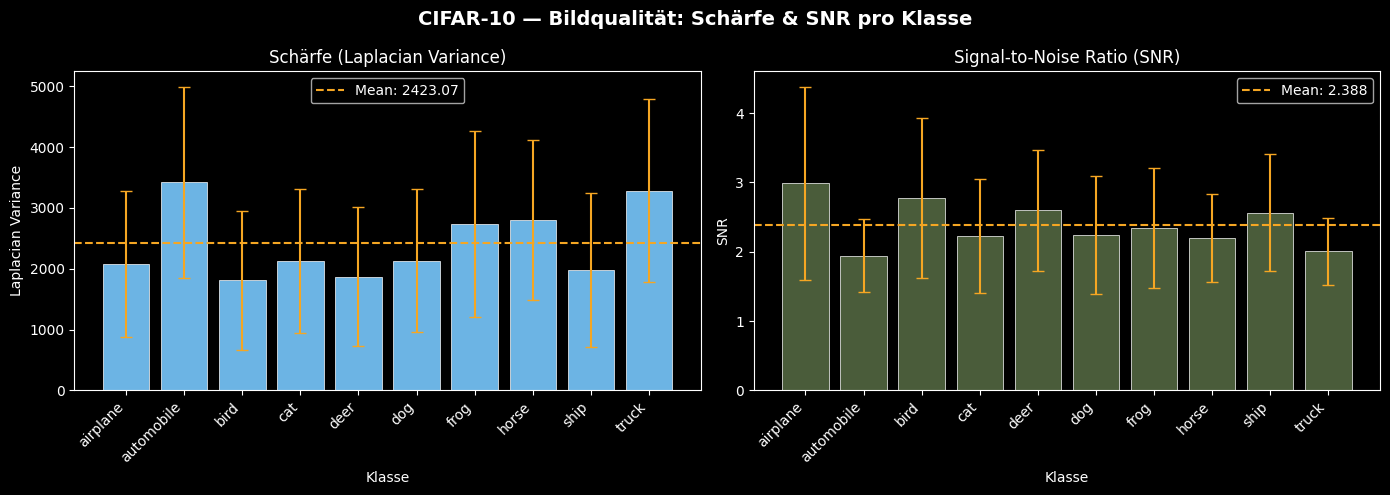


✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/02_eda_image_quality.png

Zusammenfassung Bildqualität:
Klasse          Schärfe      SNR
--------------------------------
airplane        2073.47    2.990
automobile      3419.50    1.945
bird            1807.65    2.777
cat             2123.79    2.225
deer            1869.20    2.596
dog             2133.54    2.237
frog            2738.32    2.347
horse           2802.23    2.195
ship            1979.11    2.562
truck           3283.86    2.005

Schärfste Klasse  : automobile (3419.50)
Unschärfste Klasse: bird (1807.65)


In [9]:
# =============================================================================
# Zelle 07 – Bildqualität: Schärfe und Signal-to-Noise Ratio (SNR)
# =============================================================================
# Quantitative Bildqualitäts-Analyse mit zwei Metriken:
# 1. Laplacian Variance → misst Schärfe
# 2. Signal-to-Noise Ratio (SNR) → misst Rauschen
# Ziel: Verstehen ob niedrige Modell-Performance an Bildqualität liegt.
# Sample: 1000 Bilder pro Klasse (repräsentativ, recheneffizient)
# =============================================================================

N_SAMPLE = 1000  # Bilder pro Klasse für Qualitätsanalyse

print("Berechne Bildqualitäts-Metriken...")
print(f"Sample: {N_SAMPLE} Bilder pro Klasse × {len(CLASS_NAMES)} Klassen = "
      f"{N_SAMPLE * len(CLASS_NAMES):,} Bilder\n")

# ── Metriken berechnen ────────────────────────────────────────────────────────
quality_results = {}

for class_idx, class_name in enumerate(CLASS_NAMES):
    # Sample auswählen
    mask = train_labels == class_idx
    class_images = train_images[mask][:N_SAMPLE]

    sharpness_vals = []
    snr_vals       = []

    for img in class_images:
        # Graustufenbild für Laplacian
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Schärfe: Laplacian Variance
        # Hoher Wert = scharf, niedriger Wert = unscharf
        lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        sharpness_vals.append(lap_var)

        # SNR: mean / std der Pixelwerte
        # Hoher Wert = klares Signal, niedriger Wert = verrauscht
        img_float = img.astype(np.float32)
        mean_val  = img_float.mean()
        std_val   = img_float.std()
        snr       = mean_val / std_val if std_val > 0 else 0
        snr_vals.append(snr)

    quality_results[class_name] = {
        'sharpness_mean' : np.mean(sharpness_vals),
        'sharpness_std'  : np.std(sharpness_vals),
        'snr_mean'       : np.mean(snr_vals),
        'snr_std'        : np.std(snr_vals),
    }
    print(f"  ✓ {class_name:<12} "
          f"Schärfe: {np.mean(sharpness_vals):6.2f} ± {np.std(sharpness_vals):5.2f} | "
          f"SNR: {np.mean(snr_vals):5.3f} ± {np.std(snr_vals):.3f}")

# ── Visualisierung ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CIFAR-10 — Bildqualität: Schärfe & SNR pro Klasse',
             fontsize=14, fontweight='bold')

classes      = list(quality_results.keys())
sharpness    = [quality_results[c]['sharpness_mean'] for c in classes]
sharpness_sd = [quality_results[c]['sharpness_std']  for c in classes]
snr          = [quality_results[c]['snr_mean']        for c in classes]
snr_sd       = [quality_results[c]['snr_std']         for c in classes]

# Plot 1: Schärfe
axes[0].bar(classes, sharpness, yerr=sharpness_sd, color='#6CB4E4',
            edgecolor='white', linewidth=0.5, capsize=4,
            error_kw={'ecolor': '#F5A623', 'elinewidth': 1.5})  # ← neu
axes[0].axhline(y=np.mean(sharpness), color='#F5A623', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(sharpness):.2f}')
axes[0].set_title('Schärfe (Laplacian Variance)')
axes[0].set_xlabel('Klasse')
axes[0].set_ylabel('Laplacian Variance')
axes[0].set_xticklabels(classes, rotation=45, ha='right')
axes[0].legend()

# Plot 2: SNR
axes[1].bar(classes, snr, yerr=snr_sd, color='#4A5C3A',
            edgecolor='white', linewidth=0.5, capsize=4,
            error_kw={'ecolor': '#F5A623', 'elinewidth': 1.5})  # ← neu
axes[1].axhline(y=np.mean(snr), color='#F5A623', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(snr):.3f}')
axes[1].set_title('Signal-to-Noise Ratio (SNR)')
axes[1].set_xlabel('Klasse')
axes[1].set_ylabel('SNR')
axes[1].set_xticklabels(classes, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '02_eda_image_quality.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot gespeichert: {PLOT_PATH}")

# ── Zusammenfassung ───────────────────────────────────────────────────────────
print("\nZusammenfassung Bildqualität:")
print(f"{'Klasse':<12} {'Schärfe':>10} {'SNR':>8}")
print("-" * 32)
for name in classes:
    r = quality_results[name]
    print(f"{name:<12} {r['sharpness_mean']:>10.2f} {r['snr_mean']:>8.3f}")

sharpest  = max(classes, key=lambda c: quality_results[c]['sharpness_mean'])
blurriest = min(classes, key=lambda c: quality_results[c]['sharpness_mean'])
print(f"\nSchärfste Klasse  : {sharpest} "
      f"({quality_results[sharpest]['sharpness_mean']:.2f})")
print(f"Unschärfste Klasse: {blurriest} "
      f"({quality_results[blurriest]['sharpness_mean']:.2f})")

### Zelle 07 — Bildqualität: Schärfe und SNR

#### Was
Quantitative Bildqualitäts-Analyse mit zwei Metriken:
- **Laplacian Variance** → misst Schärfe (Kantenstärke)
- **Signal-to-Noise Ratio (SNR)** → misst Rauschen
Sample: 1.000 Bilder pro Klasse (10.000 total) — repräsentativ.

#### Konzept: Laplacian Variance
Der Laplace-Operator berechnet die zweite Ableitung des Bildes:
Scharf = starke Kanten = hohe zweite Ableitung = hohe Varianz
Unscharf = schwache Kanten = niedrige zweite Ableitung = niedrige Varianz
Formel: `cv2.Laplacian(gray, cv2.CV_64F).var()`
Schwellwert ist datensatzabhängig — hier Mean = 2423 als Referenz.

#### Konzept: Signal-to-Noise Ratio (SNR)
SNR = mean(Pixelwerte) / std(Pixelwerte)
Hoher SNR = homogenes Bild, wenig Rauschen
Niedriger SNR = viel Kontrast / Rauschen
SNR und Schärfe messen verschiedene Aspekte —
ein Bild kann scharf UND verrauscht sein.

#### Ergebnisse — Schärfe

| Klasse | Schärfe | ± Std | Interpretation |
|--------|---------|-------|----------------|
| automobile | 3419 | 1576 | Schärfste — klare Kanten |
| truck | 3284 | 1511 | Scharf — ähnlich automobile |
| horse | 2802 | 1316 | Überdurchschnittlich |
| frog | 2738 | 1526 | Überdurchschnittlich |
| dog | 2134 | 1175 | Durchschnittlich |
| cat | 2124 | 1181 | Durchschnittlich |
| airplane | 2073 | 1205 | Unterdurchschnittlich |
| ship | 1979 | 1267 | Unscharf |
| deer | 1869 | 1148 | Sehr unscharf |
| **bird** | **1808** | **1146** | **Unschärfste Klasse** |

#### Ergebnisse — SNR

| Klasse | SNR | Interpretation |
|--------|-----|----------------|
| **airplane** | 2.990 | Bestes SNR — homogener Himmel |
| bird | 2.777 | Gut |
| deer | 2.596 | Überdurchschnittlich |
| ship | 2.562 | Überdurchschnittlich |
| **automobile** | 1.945 | Schlechtestes SNR |
| truck | 2.005 | Niedrig |

#### Kritische Befunde

**Befund 1 — Automobile Paradox:**
Automobile = schärfste Klasse (3419) aber niedrigstes SNR (1.945).
Erklärung: viele scharfe Kanten = hohe Pixelvarianz = niedriger SNR.
Schärfe und SNR sind komplementär, nicht redundant.

**Befund 2 — Hohe Standardabweichungen:**
Alle Klassen haben Std von 50–70% des Mittelwerts.
Beispiel: Bird Schärfe = 1808 ± 1146 → Wertebereich ~662–2954.
Das bedeutet: enorme Qualitätsvarianz innerhalb jeder Klasse.
Manche Bilder sehr scharf, andere sehr unscharf — beide in derselben Klasse.

**Befund 3 — Bird ist schwierigste Klasse:**
Niedrigste Schärfe (1808) + kleine Objekte in 32x32 =
wenige lernbare Features → erwartete niedrige Per-Class F1.

**Befund 4 — Qualität ist Datensatz-Limit, nicht Modell-Limit:**
Niedrige Schärfe bei Bird/Deer ist durch 32x32 Auflösung bedingt.
Mehr Training oder größeres Modell verbessert das nicht.
Das ist eine harte Grenze des Datensatzes.

#### Konsequenz für Training
| Befund | Konsequenz |
|--------|-----------|
| Hohe Qualitätsvarianz | Modell muss robust gegen Unschärfe sein |
| Bird unschärfste Klasse | Niedrige Bird-F1 erwartet |
| Automobile schärfste | Automobile-F1 sollte hoch sein |
| Hintergrund-Bias (Zelle 06) | Brightness Augmentation sinnvoll |

#### Ergebnis
Bildqualität ist ausreichend — kein systematisches Qualitätsproblem.
Varianz ist hoch aber konsistent über alle Klassen.
Qualitäts-Limits sind Datensatz-bedingt, nicht behebbar.
Plot gespeichert: `reports/figures/02_eda_image_quality.png` ✅

Korrelationsbereich : -0.693 – 0.885
Schwellwert HOCH    : > 0.491
Schwellwert MITTEL  : > 0.096



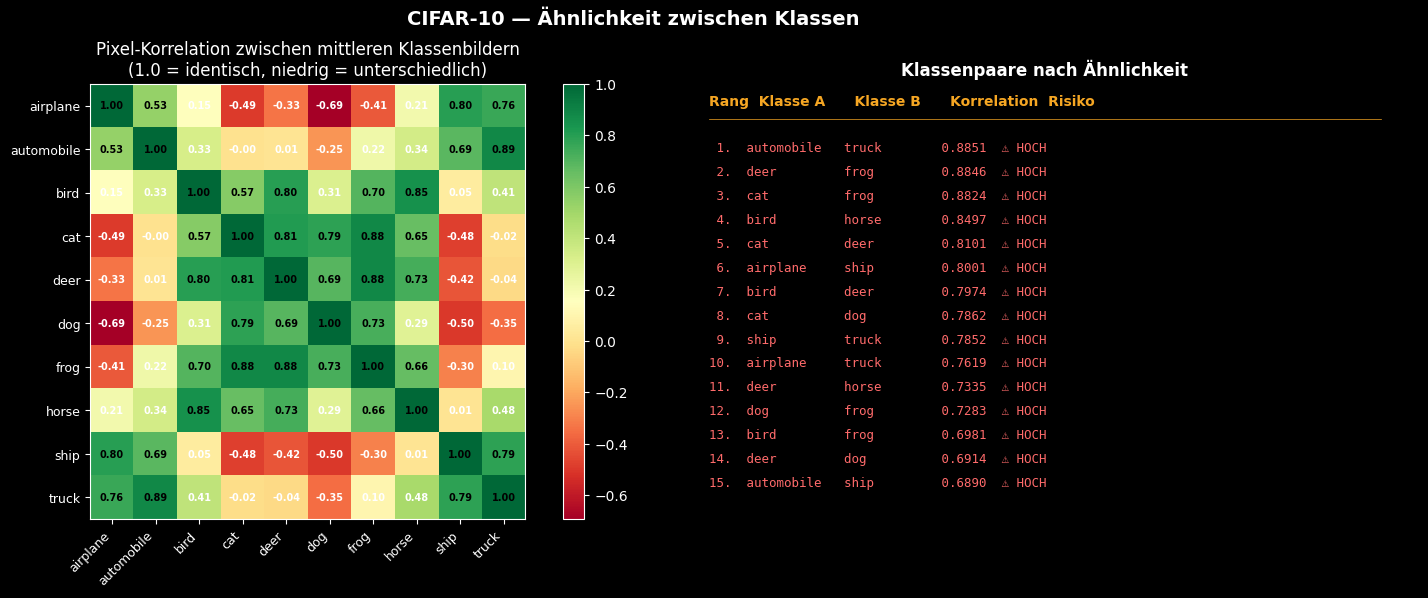

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/02_eda_class_similarity.png

Top-5 ähnlichste Klassenpaare (höchstes Verwechslungsrisiko):
Rang  Klasse A       Klasse B        Korrelation Risiko
----------------------------------------------------------
1     automobile     truck                0.8851 HOCH
2     deer           frog                 0.8846 HOCH
3     cat            frog                 0.8824 HOCH
4     bird           horse                0.8497 HOCH
5     cat            deer                 0.8101 HOCH


In [12]:
# =============================================================================
# Zelle 08 – Schwierige Klassen identifizieren
# =============================================================================
# Zwei Methoden um visuell ähnliche Klassen zu identifizieren:
# 1. Pixel-Korrelation zwischen mittleren Klassenbildern
# 2. Dynamische Schwellwerte basierend auf tatsächlichem Wertebereich
# Ziel: Vorhersage welche Klassen das Modell verwechseln wird.
# =============================================================================

# ── Methode 1: Mittlere Bilder berechnen ─────────────────────────────────────
mean_images = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = train_labels == class_idx
    mean_images[class_name] = train_images[mask].mean(axis=0)

# ── Korrelationsmatrix der mittleren Bilder ───────────────────────────────────
n_classes   = len(CLASS_NAMES)
corr_matrix = np.zeros((n_classes, n_classes))

for i, name_i in enumerate(CLASS_NAMES):
    for j, name_j in enumerate(CLASS_NAMES):
        img_i = mean_images[name_i].flatten()
        img_j = mean_images[name_j].flatten()
        corr  = np.corrcoef(img_i, img_j)[0, 1]
        corr_matrix[i, j] = corr

# ── Dynamische Schwellwerte ───────────────────────────────────────────────────
# Schwellwerte basieren auf tatsächlichem Wertebereich — nicht hardcoded
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag, 0)
corr_max = corr_no_diag.max()
corr_min = corr_no_diag.min()

thresh_high = corr_min + (corr_max - corr_min) * 0.75
thresh_mid  = corr_min + (corr_max - corr_min) * 0.50

print(f"Korrelationsbereich : {corr_min:.3f} – {corr_max:.3f}")
print(f"Schwellwert HOCH    : > {thresh_high:.3f}")
print(f"Schwellwert MITTEL  : > {thresh_mid:.3f}\n")

# ── Paare sortieren ───────────────────────────────────────────────────────────
pairs = []
for i in range(n_classes):
    for j in range(i+1, n_classes):
        pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], corr_matrix[i,j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

# ── Visualisierung ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CIFAR-10 — Ähnlichkeit zwischen Klassen',
             fontsize=14, fontweight='bold')

# Plot 1: Korrelations-Heatmap
im = axes[0].imshow(corr_matrix, cmap='RdYlGn', vmin=corr_min, vmax=1.0)
axes[0].set_xticks(range(n_classes))
axes[0].set_yticks(range(n_classes))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(CLASS_NAMES, fontsize=9)
axes[0].set_title('Pixel-Korrelation zwischen mittleren Klassenbildern\n'
                  '(1.0 = identisch, niedrig = unterschiedlich)')
plt.colorbar(im, ax=axes[0])

# Korrelationswerte in Heatmap — dynamische Textfarbe
for i in range(n_classes):
    for j in range(n_classes):
        val        = corr_matrix[i, j]
        text_color = 'black' if val > 0.5 else 'white'
        axes[0].text(j, i, f'{val:.2f}',
                    ha='center', va='center', fontsize=7,
                    color=text_color, fontweight='bold')

# Plot 2: Klassenpaare nach Ähnlichkeit
axes[1].axis('off')
axes[1].set_title('Klassenpaare nach Ähnlichkeit', fontweight='bold')

y_pos = 0.95
axes[1].text(0.05, y_pos,
            'Rang  Klasse A      Klasse B      Korrelation  Risiko',
            transform=axes[1].transAxes, fontsize=10,
            fontweight='bold', color='#F5A623')

y_pos -= 0.05
axes[1].plot([0.05, 0.95], [y_pos + 0.02, y_pos + 0.02],
            color='#F5A623', linewidth=0.5,
            transform=axes[1].transAxes)

for rank, (name_a, name_b, corr) in enumerate(pairs_sorted[:15], 1):
    y_pos -= 0.055
    if corr > thresh_high:
        color = '#FF6B6B'
        risk  = '⚠ HOCH'
    elif corr > thresh_mid:
        color = '#F5A623'
        risk  = '△ MITTEL'
    else:
        color = 'white'
        risk  = '✓ NIEDRIG'

    axes[1].text(0.05, y_pos,
                f'{rank:>2}.  {name_a:<12} {name_b:<12} {corr:.4f}  {risk}',
                transform=axes[1].transAxes, fontsize=9,
                fontfamily='monospace', color=color)

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '02_eda_class_similarity.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Top-5 Verwechslungspaare ausgeben ─────────────────────────────────────────
print("\nTop-5 ähnlichste Klassenpaare (höchstes Verwechslungsrisiko):")
print(f"{'Rang':<5} {'Klasse A':<14} {'Klasse B':<14} {'Korrelation':>12} {'Risiko'}")
print("-" * 58)
for rank, (name_a, name_b, corr) in enumerate(pairs_sorted[:5], 1):
    if corr > thresh_high:
        risk = 'HOCH'
    elif corr > thresh_mid:
        risk = 'MITTEL'
    else:
        risk = 'NIEDRIG'
    print(f"{rank:<5} {name_a:<14} {name_b:<14} {corr:>12.4f} {risk}")

### Zelle 08 — Schwierige Klassen identifizieren

#### Was
Pixel-Korrelation zwischen mittleren Klassenbildern.
Dynamische Schwellwerte basierend auf tatsächlichem Wertebereich.
Ziel: datengetriebene Vorhersage der Verwechslungspaare.

#### Methode: Pixel-Korrelation mittlerer Bilder
Mittleres Bild pro Klasse berechnen (pixelweiser Durchschnitt)
Mittlere Bilder als Vektoren flattening
Pearson-Korrelation zwischen allen Paaren berechnen
Hohe Korrelation → ähnliche Pixelstruktur → Verwechslungsrisiko
#### Dynamische Schwellwerte
Korrelationsbereich: -0.693 – 0.885
Schwellwert HOCH   : > 0.491  (oberes Viertel des Bereichs)
Schwellwert MITTEL : > 0.096  (obere Hälfte des Bereichs)
Dynamisch statt hardcoded — passt sich an jeden Datensatz an.

#### Ergebnisse — Top Verwechslungspaare

| Rang | Klasse A | Klasse B | Korrelation | Erwartete Verwechslung |
|------|----------|----------|-------------|----------------------|
| 1 | automobile | truck | 0.885 | Hoch — gleiche Form/Farbe |
| 2 | deer | frog | 0.885 | Hoch — grüner Hintergrund |
| 3 | cat | frog | 0.882 | Mittel — ähnliche Mitteltöne |
| 4 | bird | horse | 0.850 | Mittel — ähnliche Silhouetten |
| 5 | cat | deer | 0.810 | Mittel — braun/beige Töne |
| 8 | cat | dog | 0.786 | Erwartet aber niedriger als vermutet |

#### Überraschende Befunde

**Befund 1 — cat/dog nicht Top-3:**
Visuell ähnlich — aber pixel-statistisch Rang 8 (0.786).
Erklärung: Hintergründe unterscheiden sich systematisch.
Katzen: oft Innen-Hintergrund. Hunde: oft Außen-Hintergrund.
→ Hintergrund trennt die Klassen mehr als das Objekt selbst.

**Befund 2 — Negative Korrelationen:**
dog/airplane: -0.69 → pixel-statistisch gegensätzlich.
Erklärung: Airplane = hell (Himmel), Dog = dunkel (Boden/nah).
Negative Korrelation = Modell kann diese Klassen leicht trennen.

**Befund 3 — deer/frog Korrelation = 0.885:**
Nicht wegen ähnlicher Tiere — sondern wegen ähnlichem Hintergrund.
Beide: grüne Vegetation dominiert das Bild.
→ Modell könnte Hintergrundfarbe als Feature lernen.

#### Konzept: Limitierung dieser Methode
Pixel-Korrelation mittlerer Bilder ist eine grobe Approximation.
Sie misst Ähnlichkeit auf Pixelebene — nicht auf Feature-Ebene.
Ein CNN lernt Features (Kanten, Texturen, Formen) — nicht Pixel.
Daher: diese Analyse gibt Hinweise, keine Garantien.
Tatsächliche Verwechslungen werden in Notebook 06 (Confusion Matrix) gemessen.

#### Vorhersage für Confusion Matrix
Erwartete hohe Verwechslungsrate:
automobile ↔ truck    (0.885)
deer       ↔ frog     (0.885)
cat        ↔ frog     (0.882)
bird       ↔ horse    (0.850)
Wird in Notebook 06 verifiziert.

#### Ergebnis
Verwechslungspaare datengetrieben identifiziert.
Hintergrund-Bias bestätigt (deer/frog, cat/frog).
Plot gespeichert: `reports/figures/02_eda_class_similarity.png` ✅

### Zelle 09 — Fazit & Erkenntnisse

---

## EDA Fazit — CIFAR-10

### 1. Datensatz-Qualität

| Kriterium | Bewertung | Detail |
|-----------|-----------|--------|
| Datenmenge | ✅ | 60.000 Bilder (50k Train / 10k Test) |
| Klassenbalance | ✅ | Gini = 0.90 — perfekt balanciert |
| Pixelwertebereich | ✅ | 0–255 vollständig genutzt |
| Auflösung | ❌ | 32x32 — fundamentales Limit, nicht behebbar |
| Qualitätsvarianz | ⚠ | Std ~50–70% des Means — hohe Varianz innerhalb Klassen |

### 2. Pixel-Statistiken

| Befund | Wert | Konsequenz |
|--------|------|-----------|
| Hellste Klasse | airplane (142.4) | Himmel-Hintergrund dominiert |
| Dunkelste Klasse | frog (106.6) | Vegetation dominiert |
| Delta Helligkeit | 35.8 Pixel | Hintergrund-Bias Risiko |
| CIFAR-10 vs. ImageNet | +0.040 (B-Kanal) | `preprocess_input()` zwingend |

### 3. Bildqualität

| Metrik | Beste Klasse | Schlechteste Klasse |
|--------|-------------|-------------------|
| Schärfe (Laplacian) | automobile (3419) | bird (1808) |
| SNR | airplane (2.990) | automobile (1.945) |

Qualitäts-Limit ist datensatzbedingt — nicht durch Training behebbar.

### 4. Verwechslungsrisiko (Vorhersage)

| Rang | Paar | Korrelation | Risiko |
|------|------|-------------|--------|
| 1 | automobile / truck | 0.885 | Hoch |
| 2 | deer / frog | 0.885 | Hoch |
| 3 | cat / frog | 0.882 | Hoch |
| 4 | bird / horse | 0.850 | Mittel |
| 8 | cat / dog | 0.786 | Überraschend niedrig |

### 5. Realistisches Performance-Ziel

| Modell | Daten | Erwartete Accuracy |
|--------|-------|-------------------|
| Random Baseline | — | ~10% |
| ResNet50 (10k, fine-tuned) | 10k | **~70–78%** ← unser Ziel |
| ResNet50 (50k, fine-tuned) | 50k | ~85–90% |
| Mensch | — | ~94% |
| State-of-the-Art (ViT) | 50k+ | ~99.5% |

### 6. Konsequenzen für Preprocessing (Notebook 03)

| Augmentation | Begründung | Priorität |
|-------------|-----------|----------|
| `preprocess_input()` | ImageNet-Normalisierung für ResNet50 | ✅ Zwingend |
| Horizontal Flip | Hohe Pose-Varianz sichtbar in EDA | ✅ Standard |
| Random Crop | Objekte nicht immer zentriert | ✅ Standard |
| Brightness Augmentation | Hintergrund-Bias (Δ35.8 Pixel) | ✅ Begründet |
| Cutout / Mixup | Entscheidung nach Baseline | ❓ Optional |

---

**EDA abgeschlossen.**
Nächster Schritt: **Notebook 03 — Preprocessing**

---

## Notebook 02 — Abschluss: Exploratory Data Analysis

### Durchgeführte Schritte

| Zelle | Inhalt | Status |
|-------|--------|--------|
| 01 | Setup & Imports | ✅ |
| 02 | Datensatz laden (60k Bilder) | ✅ |
| 03 | Grundlegende Statistiken | ✅ |
| 04 | Klassenverteilung + Gini-Index | ✅ |
| 05 | Beispielbilder pro Klasse | ✅ |
| 06 | Pixelstatistiken (Helligkeit, Kontrast) | ✅ |
| 07 | Bildqualität (Schärfe, SNR) | ✅ |
| 08 | Schwierige Klassen identifizieren | ✅ |
| 09 | Fazit & Erkenntnisse | ✅ |

### Gespeicherte Artefakte

| Datei | Inhalt |
|-------|--------|
| `reports/figures/02_eda_class_distribution.png` | Klassenverteilung |
| `reports/figures/02_eda_sample_images.png` | Beispielbilder pro Klasse |
| `reports/figures/02_eda_pixel_statistics.png` | Helligkeit & Kontrast |
| `reports/figures/02_eda_image_quality.png` | Schärfe & SNR |
| `reports/figures/02_eda_class_similarity.png` | Klassenähnlichkeit |

### Zentrale Erkenntnisse

| Erkenntnis | Konsequenz |
|-----------|-----------|
| Perfekte Klassenbalance (Gini=0.90) | Accuracy ist valide Metrik |
| Hintergrund-Bias (Δ35.8 Pixel) | Brightness Augmentation begründet |
| Bird unschärfste Klasse (1808) | Niedrige Bird-F1 erwartet |
| automobile/truck höchste Ähnlichkeit (0.885) | Hohe Verwechslung erwartet |
| CIFAR-10 heller als ImageNet | `preprocess_input()` zwingend |
| 32x32 Auflösung | Fundamentales Limit — nicht behebbar |

### Performance-Erwartung
**Realistisches Ziel: ~70–78% Accuracy** (ResNet50, 10k Samples)

### Offene Punkte
- Cutout/Mixup Augmentation → Entscheidung nach Baseline (Notebook 04)
- Tatsächliche Verwechslungspaare → Confusion Matrix (Notebook 06)

### Nächster Schritt
**Notebook 03: `03_preprocessing.ipynb`**
Normalisierung, Augmentation, Data Pipeline aufbauen.

### Gespeicherte Plots
reports/figures/
├── 02_eda_class_distribution.png
├── 02_eda_sample_images.png
├── 02_eda_pixel_statistics.png
├── 02_eda_image_quality.png
└── 02_eda_class_similarity.png
---
*Notebook 02 abgeschlossen — Phase 1: EDA vollständig.*